# 구강 건강 지수(DOHI) 통계 분석
2021-17500 85 지민서

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, silhouette_score
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

%matplotlib inline

# 설치된 한글 폰트를 찾아서 그래프 라벨이 깨지지 않도록 한다
for font_name in ["NanumGothic", "Malgun Gothic", "AppleGothic", "Apple SD Gothic Neo"]:
    if font_name in {f.name for f in fm.fontManager.ttflist}:
        plt.rcParams["font.family"] = font_name
        break
plt.rcParams["axes.unicode_minus"] = False


## 1. 코호트 생성 및 DOHI 채점
300명의 180일 평균 행동 데이터를 생성하고, 스테판 곡선 시뮬레이션 기반 DRS와 세션 단위 시뮬레이션 기반 ARS·BES로 DOHI를 산출한다.

In [2]:
N = 300
GEN_SEED = 42

BRUSH_FREQ_CHOICES, BRUSH_FREQ_PROBS = [1, 2, 3], [0.20, 0.65, 0.15]
FOOD_TYPE_CHOICES, FOOD_TYPE_PROBS = ["high_acid", "medium", "low"], [0.30, 0.50, 0.20]
ICDAS_CHOICES = [0, 1, 2, 3, 4, 5]
ICDAS_PROBS = [0.45, 0.20, 0.15, 0.10, 0.05, 0.05]


def build_cohort(rng, n=N):
    # 변수별 임상적으로 흔한 범위 안에서 정규/범주 분포로 생성 (순서 고정)
    brush_time_sec = np.clip(rng.normal(96.6, 36.0, n), 30, 240)
    brush_force_N = np.clip(rng.normal(1.3, 0.5, n), 0.3, 5.0)
    brush_freq = rng.choice(BRUSH_FREQ_CHOICES, size=n, p=BRUSH_FREQ_PROBS)
    buccal_coverage_pct = np.clip(rng.normal(75, 15, n), 0, 100)
    occlusal_coverage_pct = np.clip(rng.normal(60, 20, n), 0, 100)
    lingual_coverage_pct = np.clip(rng.normal(45, 20, n), 0, 100)
    sugar_freq_day = np.clip(rng.normal(4.0, 1.5, n), 1, 10)
    food_type = rng.choice(FOOD_TYPE_CHOICES, size=n, p=FOOD_TYPE_PROBS)
    brush_delay_min = np.clip(rng.normal(45, 30, n), 0, 180)
    age = np.clip(rng.normal(35, 12, n), 18, 70)
    baseline_icdas = rng.choice(ICDAS_CHOICES, size=n, p=ICDAS_PROBS)

    return pd.DataFrame({
        "person_id": [f"P{i+1:04d}" for i in range(n)],
        "brush_time_sec": brush_time_sec.round(2),
        "brush_force_N": brush_force_N.round(2),
        "brush_freq": brush_freq.astype(int),
        "buccal_coverage_pct": buccal_coverage_pct.round(2),
        "occlusal_coverage_pct": occlusal_coverage_pct.round(2),
        "lingual_coverage_pct": lingual_coverage_pct.round(2),
        "sugar_freq_day": sugar_freq_day.round(2),
        "food_type": food_type,
        "brush_delay_min": brush_delay_min.round(2),
        "age": age.round(1),
        "baseline_icdas": baseline_icdas.astype(int),
    })


cohort = build_cohort(np.random.default_rng(GEN_SEED))
cohort.describe(include="all")


,person_id,brush_time_sec,brush_force_N,brush_freq,buccal_coverage_pct,occlusal_coverage_pct,lingual_coverage_pct,sugar_freq_day,food_type,brush_delay_min,age,baseline_icdas
count,300,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300,300.000000,300.000000,300.000000
unique,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN
top,P0001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,medium,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,148,NaN,NaN,NaN
mean,NaN,95.312767,1.298900,1.943333,75.186633,60.005967,42.153133,3.795000,NaN,46.608467,35.852000,1.180000
std,NaN,33.065381,0.497851,0.622963,14.011873,21.033005,20.324335,1.407069,NaN,28.682117,11.348191,1.488282
min,NaN,30.000000,0.300000,1.000000,20.270000,0.890000,0.000000,1.000000,NaN,0.000000,18.000000,0.000000
25%,NaN,72.502500,0.947500,2.000000,66.795000,46.550000,28.652500,2.830000,NaN,25.155000,27.075000,0.000000
50%,NaN,93.470000,1.330000,2.000000,75.570000,60.545000,42.390000,3.930000,NaN,44.630000,35.150000,1.000000
75%,NaN,113.657500,1.635000,2.000000,84.262500,74.857500,55.662500,4.770000,NaN,67.890000,44.025000,2.000000


In [3]:
DRS_SIM_SEED, SESSION_SIM_SEED, PROGRESSION_SEED = 642, 542, 142

RECOVERY_TIME = {"high_acid": 40, "medium": 25, "low": 10}
TROUGH_BY_TYPE = {"high_acid": 4.0, "medium": 5.3, "low": 6.3}
GRADE_PROGRESSION_PROB = {"Excellent": 0.02, "Good": 0.08, "Fair": 0.20, "Poor": 0.45}
TIME_POINTS, PLAQUE_POINTS = [0, 30, 45, 60, 120, 180, 240], [0, 12, 16, 20, 41, 50, 100]
COVERAGE_WEIGHTS = {"buccal": (8, 1.0), "occlusal": (4, 1.2), "lingual": (6, 1.5)}
TOTAL_COVERAGE_WEIGHT = sum(n_zone * w for n_zone, w in COVERAGE_WEIGHTS.values())
FREQ_FACTOR_BES = {1: 1.30, 2: 1.00, 3: 0.87}
SESSION_JITTER = {"force": 0.25, "time": 15, "coverage": 6}
PH_BASELINE, CRITICAL_PH = 7.0, 5.5
DROP_DURATION_MIN, WAKING_WINDOW_MIN, DRS_NORMALIZATION_MIN = 5, 900, 200


def simulate_day_ph(food_type, sugar_freq_day, rng=None):
    """그날의 식사 횟수만큼 스테판 곡선을 겹쳐 그려 pH 궤적을 만들고,
    pH<5.5로 내려간 시간(분)과 깊이 가중 노출량(AUC)을 함께 반환한다."""
    n_events = max(1, int(round(sugar_freq_day)))
    trough = TROUGH_BY_TYPE[food_type]
    recovery = RECOVERY_TIME[food_type]
    tau = recovery / 3
    interval = WAKING_WINDOW_MIN / n_events

    event_times = []
    for i in range(n_events):
        t0 = i * interval
        if rng is not None:
            t0 += rng.uniform(-interval * 0.2, interval * 0.2)
        event_times.append(max(0, t0))

    ph = np.full(int(WAKING_WINDOW_MIN), PH_BASELINE)
    for et in event_times:
        et_i = int(et)
        for t in range(et_i, min(len(ph), et_i + DROP_DURATION_MIN + recovery)):
            local_t = t - et_i
            if local_t < DROP_DURATION_MIN:
                candidate = PH_BASELINE + (trough - PH_BASELINE) * (local_t / DROP_DURATION_MIN)
            else:
                t_rec = local_t - DROP_DURATION_MIN
                candidate = trough + (PH_BASELINE - trough) * (1 - np.exp(-t_rec / tau))
            ph[t] = min(ph[t], candidate)

    minutes_below = int(np.sum(ph < CRITICAL_PH))
    auc_below = float(np.sum(np.maximum(0.0, CRITICAL_PH - ph)))
    return minutes_below, auc_below


def p_risk(force_n):
    # 압력-마모 위험 곡선: 3.0N, 3.9N을 기점으로 구간별로 가팔라진다
    if force_n <= 3.0:
        return force_n / 3.0 * 25
    if force_n <= 3.9:
        return 25 + (force_n - 3.0) / 0.9 * 45
    return min(100.0, 70 + (force_n - 3.9) * 15)


def session_ars(force_n, duration_sec, food_type, brush_delay_min):
    time_factor = duration_sec / 120
    if food_type == "high_acid" and brush_delay_min < 30:
        penalty = 1.0 + 1.5 * (1 - brush_delay_min / 30)
    else:
        penalty = 1.0
    return min(100.0, p_risk(force_n) * time_factor * penalty)


def session_bes(duration_sec, buccal_pct, occlusal_pct, lingual_pct, brush_freq):
    freq_factor = FREQ_FACTOR_BES[min(int(brush_freq), 3)]
    t_ineff = 100.0 - np.interp(duration_sec, TIME_POINTS, PLAQUE_POINTS)
    (bn, bw), (on, ow), (ln, lw) = COVERAGE_WEIGHTS.values()
    weighted_cov = (buccal_pct * bn * bw + occlusal_pct * on * ow +
                    lingual_pct * ln * lw) / TOTAL_COVERAGE_WEIGHT
    c_ineff = 100.0 - weighted_cov
    return min(100.0, freq_factor * (0.4 * t_ineff + 0.6 * c_ineff))


def simulate_person_ars_bes(rng, row):
    # 하루 양치 횟수만큼 개별 세션을 시뮬레이션해서 평균낸다
    n_sessions = int(row["brush_freq"])
    ars_vals, bes_vals = [], []
    for _ in range(n_sessions):
        force = float(np.clip(rng.normal(row["brush_force_N"], SESSION_JITTER["force"]), 0.1, 5.0))
        duration = float(np.clip(rng.normal(row["brush_time_sec"], SESSION_JITTER["time"]), 20, 240))
        buccal = float(np.clip(rng.normal(row["buccal_coverage_pct"], SESSION_JITTER["coverage"]), 0, 100))
        occlusal = float(np.clip(rng.normal(row["occlusal_coverage_pct"], SESSION_JITTER["coverage"]), 0, 100))
        lingual = float(np.clip(rng.normal(row["lingual_coverage_pct"], SESSION_JITTER["coverage"]), 0, 100))
        ars_vals.append(session_ars(force, duration, row["food_type"], row["brush_delay_min"]))
        bes_vals.append(session_bes(duration, buccal, occlusal, lingual, n_sessions))
    return float(np.mean(ars_vals)), float(np.mean(bes_vals))


def score_cohort(df):
    df = df.copy()
    rng_drs = np.random.default_rng(DRS_SIM_SEED)
    rng_session = np.random.default_rng(SESSION_SIM_SEED)

    minutes = [simulate_day_ph(r.food_type, r.sugar_freq_day, rng_drs)[0] for r in df.itertuples()]
    df["DRS"] = np.round(np.minimum(100.0, np.array(minutes) / DRS_NORMALIZATION_MIN * 100), 2)

    ars_bes = [simulate_person_ars_bes(rng_session, row) for _, row in df.iterrows()]
    df["ARS"] = np.round([v[0] for v in ars_bes], 2)
    df["BES"] = np.round([v[1] for v in ars_bes], 2)

    # DOHI = 100 - (0.45*DRS + 0.25*ARS + 0.30*BES), 세 지표 모두 높을수록 나쁨
    df["DOHI"] = (100 - (0.45 * df["DRS"] + 0.25 * df["ARS"] + 0.30 * df["BES"])).clip(0, 100).round(2)
    df["grade"] = np.select(
        [df["DOHI"] >= 90, df["DOHI"] >= 75, df["DOHI"] >= 60],
        ["Excellent", "Good", "Fair"], default="Poor",
    )

    rng_prog = np.random.default_rng(PROGRESSION_SEED)
    prob = df["grade"].map(GRADE_PROGRESSION_PROB).to_numpy()
    increment = rng_prog.binomial(1, prob)
    df["final_icdas"] = np.minimum(df["baseline_icdas"] + increment, 6)
    df["progressed"] = df["final_icdas"] > df["baseline_icdas"]
    return df


cohort = score_cohort(cohort)
cohort[["DRS", "ARS", "BES", "DOHI"]].describe()


,DRS,ARS,BES,DOHI
count,300.000000,300.000000,300.000000,300.000000
mean,8.766667,9.237033,54.705433,77.334200
std,10.511925,5.683309,11.222330,5.827388
min,0.000000,0.590000,31.800000,56.150000
25%,2.000000,4.977500,47.287500,74.092500
50%,4.000000,8.460000,53.535000,78.640000
75%,12.000000,12.082500,61.477500,81.502500
max,42.000000,31.920000,93.780000,87.450000


In [4]:
print(cohort["grade"].value_counts())
print("우식 진행률:", cohort["progressed"].mean())


grade
Good    218
Fair     79
Poor      3
Name: count, dtype: int64
우식 진행률: 0.13


## 2. 통계 분석
### 2.1 DRS 공식별 예측력 비교
DRS를 4가지 방식으로 계산해보고, DRS 단독과 DOHI(재계산) 각각이 실제 우식 진행 여부(progressed)를 얼마나 잘 구분하는지 ROC-AUC로 비교한다.

In [5]:
def analytic_drs_v1(df):
    # 양치 지연 시간 기반 선형 근사식 (스테판 곡선 시뮬레이션을 쓰기 전 버전)
    recovery_time = df["food_type"].map(RECOVERY_TIME)
    dem_per_exposure = (recovery_time - df["brush_delay_min"]).clip(lower=0)
    det = dem_per_exposure * df["sugar_freq_day"]
    return (det / 120 * 100).clip(upper=100).to_numpy()


def cohens_d(x, y):
    pooled_std = np.sqrt(((len(x) - 1) * x.std(ddof=1) ** 2 +
                           (len(y) - 1) * y.std(ddof=1) ** 2) / (len(x) + len(y) - 2))
    return (x.mean() - y.mean()) / pooled_std


rng_variant = np.random.default_rng(123)
sim = [simulate_day_ph(r.food_type, r.sugar_freq_day, rng_variant) for r in cohort.itertuples()]
cohort["dem_minutes"] = [m for m, _ in sim]
cohort["dem_auc"] = [a for _, a in sim]
_, worst_auc = simulate_day_ph("high_acid", 5, rng=None)

X = pd.get_dummies(cohort[["sugar_freq_day", "brush_delay_min", "food_type"]],
                    columns=["food_type"], drop_first=True)
y = cohort["progressed"].astype(int).to_numpy()
drs_v4 = LogisticRegression(max_iter=2000).fit(X, y).predict_proba(X)[:, 1] * 100

variants = {
    "v1_원본(선형근사식)": analytic_drs_v1(cohort),
    "v2_실측 pH<5.5 시간": np.minimum(100, cohort["dem_minutes"] / 200 * 100).to_numpy(),
    "v3_실측 AUC(깊이가중)": np.minimum(100, cohort["dem_auc"] / worst_auc * 100).to_numpy(),
    "v4_로지스틱회귀 위험도": drs_v4,
}

ars_arr, bes_arr = cohort["ARS"].to_numpy(), cohort["BES"].to_numpy()
for name, drs_arr in variants.items():
    dohi_variant = np.clip(100 - (0.45 * drs_arr + 0.25 * ars_arr + 0.30 * bes_arr), 0, 100)
    auc_drs = roc_auc_score(y, drs_arr)
    auc_dohi = roc_auc_score(y, 100 - dohi_variant)
    d = cohens_d(drs_arr[y == 1], drs_arr[y == 0])
    print(f"{name:20s} DRS AUC={auc_drs:.4f}  DOHI AUC={auc_dohi:.4f}  Cohen's d={d:.3f}")


v1_원본(선형근사식)         DRS AUC=0.5917  DOHI AUC=0.6676  Cohen's d=0.342
v2_실측 pH<5.5 시간      DRS AUC=0.6392  DOHI AUC=0.7207  Cohen's d=0.733
v3_실측 AUC(깊이가중)      DRS AUC=0.6375  DOHI AUC=0.6923  Cohen's d=0.669
v4_로지스틱회귀 위험도        DRS AUC=0.6972  DOHI AUC=0.7460  Cohen's d=0.788


### 2.2 상관관계
DOHI 및 하위 지표와 행동 변수 13개 사이의 Pearson 상관계수를 본다.

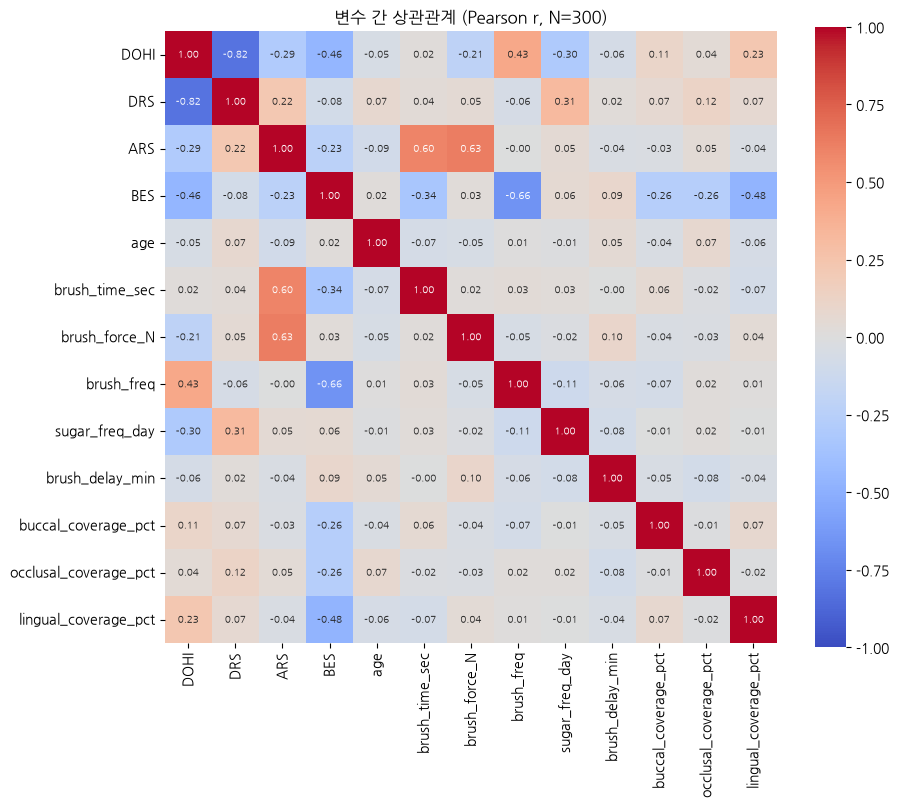

DRS                     -0.819545
BES                     -0.456755
brush_freq               0.429420
sugar_freq_day          -0.300768
ARS                     -0.290597
lingual_coverage_pct     0.230296
brush_force_N           -0.212634
buccal_coverage_pct      0.105181
brush_delay_min         -0.062855
age                     -0.048966
occlusal_coverage_pct    0.041836
brush_time_sec           0.020794
Name: DOHI, dtype: float64

In [6]:
corr_cols = ["DOHI", "DRS", "ARS", "BES", "age", "brush_time_sec", "brush_force_N",
             "brush_freq", "sugar_freq_day", "brush_delay_min",
             "buccal_coverage_pct", "occlusal_coverage_pct", "lingual_coverage_pct"]
corr = cohort[corr_cols].corr(method="pearson")

plt.figure(figsize=(9.5, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, annot_kws={"size": 7.5})
plt.title(f"변수 간 상관관계 (Pearson r, N={len(cohort)})")
plt.tight_layout()
plt.show()

corr["DOHI"].drop("DOHI").sort_values(key=np.abs, ascending=False)


### 2.3 집단별 DOHI 차이
연령대와 하루 양치 빈도에 따라 DOHI가 다른지 ANOVA와 Kruskal-Wallis로 검정하고, 전체 행동 변수에 대한 다중회귀분석을 진행한다.

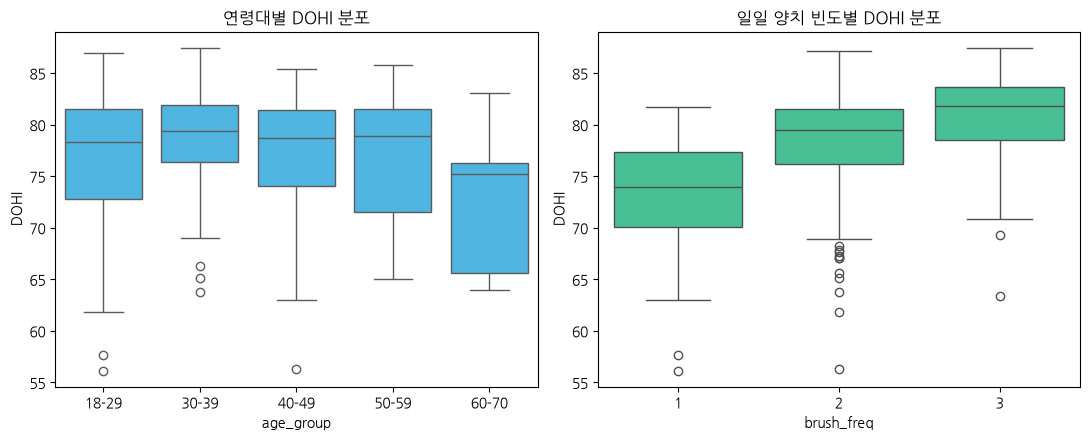

[연령대] ANOVA F=2.344 p=0.0549 / Kruskal-Wallis H=5.681 p=0.2243
[양치빈도] ANOVA F=37.566 p=0.0000 / Kruskal-Wallis H=67.771 p=0.0000


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     1      2   5.4629    0.0  3.706  7.2198   True
     1      3   7.7501    0.0 5.4506 10.0495   True
     2      3   2.2871 0.0177 0.3237  4.2506   True
---------------------------------------------------


In [7]:
cohort["age_group"] = pd.cut(
    cohort["age"], bins=[18, 30, 40, 50, 60, 71], right=False,
    labels=["18-29", "30-39", "40-49", "50-59", "60-70"],
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.boxplot(data=cohort, x="age_group", y="DOHI", ax=axes[0], color="#38bdf8")
axes[0].set_title("연령대별 DOHI 분포")
sns.boxplot(data=cohort, x="brush_freq", y="DOHI", ax=axes[1], color="#34d399")
axes[1].set_title("일일 양치 빈도별 DOHI 분포")
plt.tight_layout()
plt.show()


def group_test(col, label):
    groups = [g["DOHI"].to_numpy() for _, g in cohort.groupby(col, observed=True)]
    f_stat, p_anova = stats.f_oneway(*groups)
    h_stat, p_kw = stats.kruskal(*groups)
    print(f"[{label}] ANOVA F={f_stat:.3f} p={p_anova:.4f} / "
          f"Kruskal-Wallis H={h_stat:.3f} p={p_kw:.4f}")
    if p_anova < 0.05 or p_kw < 0.05:
        print(pairwise_tukeyhsd(cohort["DOHI"], cohort[col].astype(str)))


group_test("age_group", "연령대")
group_test("brush_freq", "양치빈도")


In [8]:
model = smf.ols(
    "DOHI ~ age + C(brush_freq) + sugar_freq_day + brush_time_sec + brush_force_N + "
    "brush_delay_min + buccal_coverage_pct + occlusal_coverage_pct + lingual_coverage_pct",
    data=cohort,
).fit()
print(f"R-squared={model.rsquared:.3f} (adj. {model.rsquared_adj:.3f}), N={int(model.nobs)}")

sig = model.pvalues[model.pvalues < 0.05].drop("Intercept", errors="ignore")
for var in sig.index:
    print(f"{var:28s} coef={model.params[var]:+.3f}  p={model.pvalues[var]:.4f}")


R-squared=0.369 (adj. 0.347), N=300
C(brush_freq)[T.2]           coef=+4.789  p=0.0000
C(brush_freq)[T.3]           coef=+7.131  p=0.0000
sugar_freq_day               coef=-1.070  p=0.0000
brush_force_N                coef=-2.306  p=0.0000
buccal_coverage_pct          coef=+0.046  p=0.0195
lingual_coverage_pct         coef=+0.062  p=0.0000


### 2.4 K-means 페르소나
k=2~6에 대해 실루엣 점수를 비교해 군집 수를 정하고, 최종 채택한 k=4로 각 군집에 이름을 붙인다.

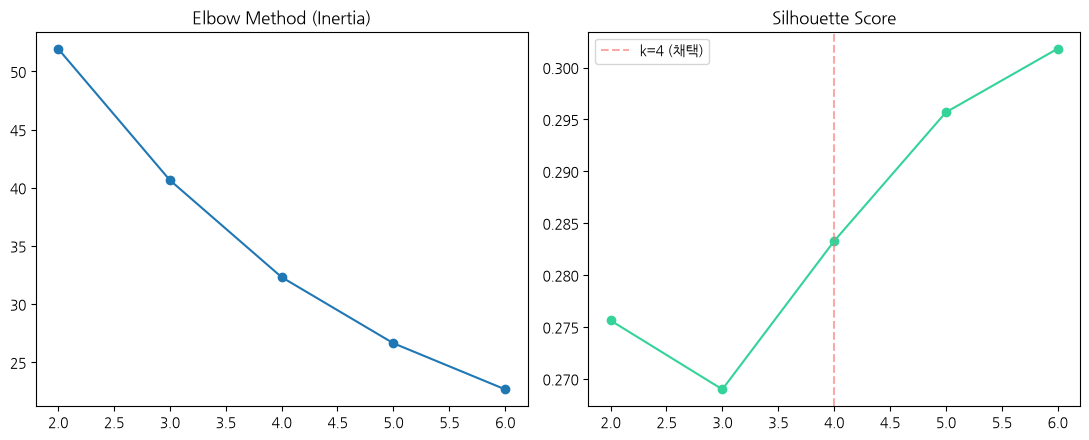

k=2: silhouette=0.276
k=3: silhouette=0.269
k=4: silhouette=0.283
k=5: silhouette=0.296
k=6: silhouette=0.302


In [9]:
x_scaled = cohort[["DRS", "ARS", "BES"]].rank(pct=True).to_numpy()

ks = range(2, 7)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(x_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(x_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(list(ks), inertias, marker="o")
axes[0].set_title("Elbow Method (Inertia)")
axes[1].plot(list(ks), sils, marker="o", color="#34d399")
axes[1].axvline(4, color="#f87171", linestyle="--", alpha=0.6, label="k=4 (채택)")
axes[1].set_title("Silhouette Score")
axes[1].legend()
plt.tight_layout()
plt.show()

for k, s in zip(ks, sils):
    print(f"k={k}: silhouette={s:.3f}")


In [10]:
PERSONA_NAME_MAP = {"drs": "당과다형", "ars": "과압마모형", "bes": "저위생형"}


def name_persona(z_drs, z_ars, z_bes):
    scores = {"drs": z_drs, "ars": z_ars, "bes": z_bes}
    dominant = max(scores, key=scores.get)
    return PERSONA_NAME_MAP[dominant] if scores[dominant] > 0.3 else "균형형"


labels = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(x_scaled)
pop_mean, pop_std = cohort[["DRS", "ARS", "BES"]].mean(), cohort[["DRS", "ARS", "BES"]].std()

personas = []
for c in range(4):
    mask = labels == c
    cmean = cohort.loc[mask, ["DRS", "ARS", "BES"]].mean()
    z_drs = (cmean["DRS"] - pop_mean["DRS"]) / pop_std["DRS"]
    z_ars = (cmean["ARS"] - pop_mean["ARS"]) / pop_std["ARS"]
    z_bes = (cmean["BES"] - pop_mean["BES"]) / pop_std["BES"]
    personas.append({
        "name": name_persona(z_drs, z_ars, z_bes),
        "n": int(mask.sum()),
        "dohi_mean": round(cohort.loc[mask, "DOHI"].mean(), 2),
        "drs_mean": round(cmean["DRS"], 2),
        "ars_mean": round(cmean["ARS"], 2),
        "bes_mean": round(cmean["BES"], 2),
    })

pd.DataFrame(personas)


,name,n,dohi_mean,drs_mean,ars_mean,bes_mean
0,과압마모형,76,72.67,17.83,15.09,51.80
1,당과다형,68,75.52,14.12,4.37,56.78
2,저위생형,77,77.89,1.64,7.09,65.34
3,균형형,79,82.85,2.39,9.89,45.35
